# 2-5. 카이제곱 독립성 검정

성별과 서비스 만족도가 서로 관련 있는지 확인한다.

- 두 변수 모두 범주형이므로 카이제곱 독립성 검정을 사용한다.
- 성별에 따라 만족도 분포가 달라지는지 검정한다.

## 이 실습의 학습 기준

이 노트북은 한 가지 함수의 결과만 확인하지 않고 다음 흐름으로 학습한다.

1. 데이터 구조에 맞는 검정 방법과 가정을 확인한다.
2. 같은 목적의 방법이 여러 개면 모두 실행해 결과를 비교한다.
3. 일부러 적합하지 않은 방법도 비교할 때는, 왜 최종 결론에 사용하지 않는지 밝힌다.
4. 전제검정 결과가 본 검정 선택에 어떻게 연결되는지 확인한다.
5. p-value뿐 아니라 차이의 방향과 크기까지 해석한다.
6. p-value가 `0.0000`으로 보이는 것은 반올림 결과이며, 실제 확률이 0이라는 뜻은 아니다.
7. 유의수준 α=0.05에서 `p-value < 0.05`면 귀무가설을 기각하고, `p-value >= 0.05`면 귀무가설을 기각하지 못한다.

In [1]:
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

satisfaction_df = pd.read_csv(
    "datas2/성별에따른만족도.csv",
    encoding="euc-kr"
)

print(satisfaction_df.head())
print(satisfaction_df.columns)

   만족도  성별
0  불만족  남성
1   보통  여성
2  불만족  여성
3   보통  남성
4   만족  여성
Index(['만족도', '성별'], dtype='str')


## 1. 이 실습에서 정규성 검정을 하지 않는 이유

성별과 만족도는 숫자의 크기나 평균에 의미가 있는 연속형 변수가 아니라 범주형 변수다. 따라서 다음 검정은 이 문제에 적용하지 않는다.

- KS-test·Shapiro-Wilk: 연속형 자료의 분포가 정규분포인지 확인하는 검정
- Levene: 독립된 연속형 집단들의 분산이 같은지 확인하는 검정
- t-검정·ANOVA: 연속형 결과변수의 평균을 비교하는 검정

이 실습에서는 범주의 **빈도 분포**를 비교하는 카이제곱 독립성 검정을 사용한다. 즉, 모든 실습에서 같은 함수를 실행하는 것이 아니라 같은 선택 기준을 적용한다.

## 2. 교차표와 가설 설정

- 귀무가설(H₀): 성별과 만족도는 서로 독립이다.
- 대립가설(H₁): 성별과 만족도는 서로 독립이 아니다.

In [2]:
contingency_table = pd.crosstab(
    satisfaction_df["성별"],
    satisfaction_df["만족도"]
)

print("관측 빈도")
display(contingency_table)

관측 빈도


만족도,만족,보통,불만족
성별,,,
남성,50,40,10
여성,40,30,30


성별별 만족도 비율(%)


만족도,만족,보통,불만족
성별,,,
남성,50.0,40.0,10.0
여성,40.0,30.0,30.0


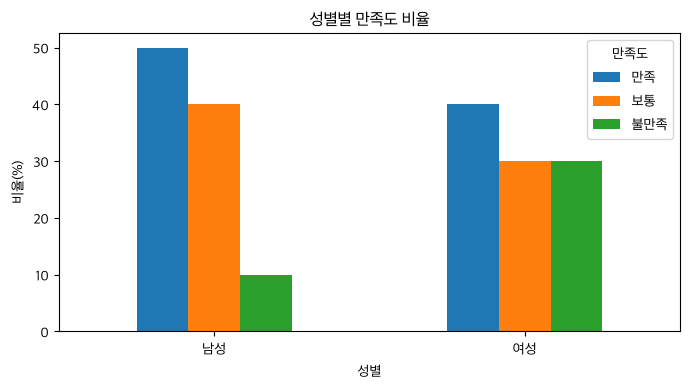

In [3]:
satisfaction_ratio = contingency_table.div(
    contingency_table.sum(axis=1),
    axis=0
) * 100

print("성별별 만족도 비율(%)")
display(satisfaction_ratio.round(1))

satisfaction_ratio.plot(kind="bar", figsize=(7, 4))
plt.ylabel("비율(%)")
plt.title("성별별 만족도 비율")
plt.xticks(rotation=0)
plt.legend(title="만족도")
plt.tight_layout()
plt.show()

## 3. Pearson 카이제곱과 우도비 G-test 비교

두 검정은 같은 독립성 가설을 검정하지만 관측 빈도와 기대 빈도의 차이를 측정하는 방식이 다르다.

- Pearson 카이제곱: 제곱 차이를 기대 빈도로 나누어 합한다. 수업의 주 검정으로 사용한다.
- 우도비 G-test: 관측 빈도와 기대 빈도의 로그 우도비를 사용한다.

두 방법을 모두 실행해 결과가 같은 방향인지 비교한다.

In [4]:
pearson_chi = stats.chi2_contingency(
    contingency_table,
    correction=False
)
likelihood_ratio = stats.chi2_contingency(
    contingency_table,
    correction=False,
    lambda_="log-likelihood"
)

independence_comparison = pd.DataFrame({
    "검정 방법": ["Pearson 카이제곱", "우도비 G-test"],
    "검정통계량": [pearson_chi.statistic, likelihood_ratio.statistic],
    "자유도": [pearson_chi.dof, likelihood_ratio.dof],
    "p-value": [pearson_chi.pvalue, likelihood_ratio.pvalue]
})
independence_comparison["결론"] = independence_comparison["p-value"].apply(
    lambda p: "성별과 만족도 관련 있음" if p < 0.05 else "관련성 증거 부족"
)

display(independence_comparison.round(4))

# 이후 기대 빈도, 잔차, 효과크기는 수업의 주 검정인 Pearson 결과를 사용한다.
chi2 = pearson_chi.statistic
p_value = pearson_chi.pvalue
dof = pearson_chi.dof
expected = pearson_chi.expected_freq

,검정 방법,검정통계량,자유도,p-value,결론
0,Pearson 카이제곱,12.5397,2,0.0019,성별과 만족도 관련 있음
1,우도비 G-test,13.0118,2,0.0015,성별과 만족도 관련 있음


## 4. 기대 빈도로 카이제곱 검정 조건 확인

카이제곱 근사 검정은 기대 빈도가 너무 작으면 불안정할 수 있다. 기대 빈도를 먼저 확인하고 Pearson 카이제곱 결과를 최종 해석한다.

기대 빈도가 작다면 범주를 이론적으로 타당하게 합치거나, 정확검정 또는 Monte Carlo 방법을 검토한다. 기본 Fisher 정확검정은 주로 2×2 표에서 배우므로 현재 2×3 표에는 바로 적용하지 않는다.

In [5]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("독립을 가정했을 때의 기대 빈도")
display(expected_table.round(2))

minimum_expected = expected_table.to_numpy().min()
print(f"가장 작은 기대 빈도: {minimum_expected:.2f}")

if minimum_expected >= 5:
    print("모든 기대 빈도가 5 이상이므로 카이제곱 근사 조건을 충족한다.")
else:
    print("기대 빈도가 작은 셀이 있으므로 정확검정이나 범주 재구성을 검토한다.")

print(f"Pearson 카이제곱 p-value: {p_value:.4f}")

독립을 가정했을 때의 기대 빈도


만족도,만족,보통,불만족
성별,,,
남성,45.0,35.0,20.0
여성,45.0,35.0,20.0


가장 작은 기대 빈도: 20.00
모든 기대 빈도가 5 이상이므로 카이제곱 근사 조건을 충족한다.
Pearson 카이제곱 p-value: 0.0019


## 5. 어떤 범주가 차이를 만들었는지 확인

전체 카이제곱 검정은 두 변수가 관련 있다는 사실만 알려준다. 표준화 잔차로 실제 빈도와 기대 빈도의 차이가 큰 셀을 확인한다.

- 양수: 실제 관측 빈도가 기대 빈도보다 많다.
- 음수: 실제 관측 빈도가 기대 빈도보다 적다.
- 절댓값이 클수록 전체 카이제곱 통계량에 더 크게 기여한다.

In [6]:
standardized_residuals = (
    contingency_table - expected_table
) / (expected_table ** 0.5)

print("표준화 잔차")
display(standardized_residuals.round(2))

표준화 잔차


만족도,만족,보통,불만족
성별,,,
남성,0.75,0.85,-2.24
여성,-0.75,-0.85,2.24


## 6. Cramér's V로 관계 크기 확인

p-value는 관련성 존재 여부를 판단하지만 관계의 크기를 알려주지 않는다. Cramér's V는 0에서 1 사이로 관계 크기를 나타낸다. 크기 해석 기준은 분야와 표의 크기에 따라 달라질 수 있으므로 절대적인 등급으로 단정하지 않는다.

In [7]:
sample_size = contingency_table.to_numpy().sum()
smaller_dimension = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = (chi2 / (sample_size * smaller_dimension)) ** 0.5
print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.2504


## 7. 분석 결과

- 범주형 자료이므로 KS-test, Shapiro-Wilk, Levene, t-검정은 적용하지 않았다.
- 모든 기대 빈도가 20 이상이어서 카이제곱 근사 검정 조건을 충족했다.
- Pearson 카이제곱 p-value는 0.0019, G-test p-value는 0.0015로 두 방법 모두 성별과 만족도가 관련 있다는 결론을 보였다.
- 수업의 주 방법인 Pearson 카이제곱 결과에 따라 독립이라는 귀무가설을 기각한다.
- 남성의 불만족 비율은 10%, 여성은 30%였고, 불만족 범주의 표준화 잔차 절댓값이 2.24로 가장 컸다.
- Cramér's V는 0.2504로 관계가 유의하더라도 매우 강한 관계라고 단정할 수준은 아니다.
- 이 결과는 성별이 만족도를 직접 결정한다는 인과관계를 뜻하지 않는다.